# Aula 07 - Aprendizado Supervisionado - Parte 1 (Regressão Linear Simples & Scikit-Learn Pipeline)

**Disciplina:** Aprendizado de Máquina e Redes Neurais  
**Professor:** Eduardo Lázaro Roesler de Oliveira  
**Instituição:** UNIVEM — Centro Universitário de Marília  

---

> [!NOTE]
> 🔙 **De onde viemos:** Na Aula 06, aprendemos a explorar e visualizar graficamente as relações lineares entre variáveis. Agora que conseguimos enxergar que quando a metragem de uma casa sobe o preço também tende a subir, é hora de ensinar a máquina a traçar a melhor reta preditiva possível.
> 🎯 **Objetivo Principal da Aula:** Compreender o paradigma do **Aprendizado Supervisionado**, formalizar a separação entre variáveis explicativas ($X$) e a variável alvo ($y$), dominar a divisão de **Treino e Teste (`train_test_split`)**, treinar o modelo de **Regressão Linear** (`fit`/`predict`) e avaliar o erro com métricas reais ($R^2$ e MAE).
> 🚀 **Para onde vamos:** Na próxima aula ('Aprendizado Supervisionado - Parte 2'), enfrentaremos um novo tipo de problema: e quando a resposta que queremos prever não for um número contínuo (como R$ 500.000), mas uma decisão categórica de **SIM ou NÃO** (como 'Aprovar Empréstimo', 'Cliente Caloteiro' ou 'Transação Fraudulenta')?

---

## Organização Tática da Aula

| Módulo | Atividade | Foco Pedagógico |
| :--- | :--- | :--- |
| **Módulo 1** | **Fundamentação Teórica & Contexto** | O paradigma supervisionado, $X$ vs $y$, Regressão vs Classificação e a intuição da reta de regressão. |
| **Módulo 2** | **O Pipeline de Machine Learning no Scikit-Learn** | As 6 etapas do ciclo de ML, divisão treino/teste e métricas de erro sem mistério. |
| **Módulo 3** | **Prática Guiada no Google Colab** | 8 blocos de código em Python minuciosamente comentados linha por linha com caixas de dúvidas. |
| **Módulo 4** | **Prática Orientada & Experimentação Fácil** | Previsão personalizada de consumo de combustível alterando peso e semente. |
| **Módulo 5** | **Checklist de Autonomia & Bibliografia** | Autoavaliação do estudante e referências oficiais. |

---

## Módulo 1: Fundamentação Teórica & Contexto do Mundo Real

### 1.1 O Paradigma do Aprendizado Supervisionado
Imagine que você está ensinando uma criança a reconhecer o preço de uma casa só olhando o tamanho dela. Você mostra várias casas (com o tamanho em m²) e, para cada uma, já diz o preço certo. Depois de ver dezenas de exemplos, a criança começa a "sentir" o padrão: quanto maior a casa, maior o preço.

É exatamente isso que fazemos no **Aprendizado Supervisionado**: damos ao algoritmo um monte de exemplos já resolvidos (entrada + resposta certa) para que ele aprenda sozinho a regra que liga uma coisa à outra.

- **$X$ (entrada / feature):** a característica que usamos para prever algo. Ex: tamanho do imóvel em m².
- **$y$ (saída / target / rótulo):** o resultado que queremos prever. Ex: preço do imóvel em R$.

O objetivo é que o algoritmo aprenda uma **função matemática $f(X)$** capaz de transformar uma entrada nova (uma casa que ele nunca viu) em uma previsão de saída ($\hat{y}$, "y chapéu", que significa "valor previsto pela IA"):

$$\hat{y} = f(X)$$

```mermaid
graph LR
    A["📏 VARIÁVEL ENTRADA (X)<br/>Ex: Tamanho do Imóvel (m²)"] --> B["📐 RETA DE REGRESSÃO<br/>y = a*x + b"]
    B --> C["💰 PREVISÃO SAÍDA (y)<br/>Ex: Preço em R$"]
```

> [!TIP]
> 🚀 **Analogia Geek — O Treinamento Jedi / Mestre Yoda:**
> Treinar um modelo de Regressão Linear é como o treinamento Jedi em Dagobah. No começo, o modelo erra feio (joga pedras longe do alvo). A cada passagem nos dados de treino, o algoritmo ajusta a inclinação da reta $a$ e a altura $b$ usando o erro como feedback, até equilibrar a reta perfeita na Força!

> [!NOTE]
> 💡 **Curiosidade da Aula — Carl Friedrich Gauss & O Planeta Ceres:**
> Em **1795, o lendário matemático Carl Friedrich Gauss** (com apenas 18 anos!) inventou o Método dos Mínimos Quadrados (a base matemática da Regressão Linear). Em 1801, ele usou esse método para calcular a órbita exata do planeta anão **Ceres** a partir de pouquíssimas observações astronômicas incompletas! Ele previu onde o planeta reapareceria no céu com precisão cirúrgica!  
> 🔗 **Documentação Scikit-Learn:** [scikit-learn LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)  
> 🎥 **Vídeo Recomendado:** [StatQuest: Linear Regression (YouTube)](https://www.youtube.com/watch?v=nk2CQITm_eo)

> [!IMPORTANT]
> 💡 **Em 1 Frase:** $X$ representa os dados de entrada que já possuímos, $y$ é o resultado real que queremos prever, e a Regressão Linear descobre a reta $y = a \cdot x + b$ que melhor conecta ambos.

---

## Módulo 2: O Mecanismo por Dentro & Regras Práticas

### 2.1 As 6 Etapas Indispensáveis de um Modelo de ML

```
[1. Carregar Dados] ➔ [2. Separar X e y] ➔ [3. Divisão Treino e Teste]
                                                      │
[6. Avaliar Métricas] ─── [5. Fazer Previsões] ─── [4. Treinar Modelo (fit)]
```

> [!IMPORTANT]
> 💡 **Em 1 Frase:** O ciclo de Machine Learning consiste em preparar os dados, dividi-los em treino/teste, treinar o algoritmo com `.fit()`, fazer previsões com `.predict()` e medir o erro com métricas numéricas.

---

## Módulo 3: Prática Guiada no Google Colab

Abra o [Google Colab](https://colab.research.google.com), crie um novo Notebook e acompanhe os blocos de código abaixo.

> [!NOTE]
> **Roteiro de estudo:** acompanhe sempre esta mesma história: dados de entrada (`X`), resposta esperada (`y`), treino, previsão e avaliação. `fit()` significa “aprender com os exemplos” e `predict()` significa “dar uma resposta para novos dados”. Execute os blocos na ordem, pois cada um usa resultados do anterior.

---

### Bloco 3.1 — Importação das Bibliotecas de Machine Learning

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Quais módulos do Scikit-Learn estamos importando?**  
> `train_test_split` para divisão de dados, `LinearRegression` para o algoritmo da reta e `r2_score`, `mean_absolute_error` para medir os erros em R$.

In [1]:
# 1. Importamos as bibliotecas de suporte matemático, estatístico e visual
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Importamos a função de divisão de dados treino/teste do Scikit-Learn
from sklearn.model_selection import train_test_split

# 3. Importamos o modelo de Regressão Linear
from sklearn.linear_model import LinearRegression

# 4. Importamos as métricas de avaliação de desempenho (R², MAE e MSE)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 5. Exibimos a confirmação de carregamento no console
print("--- CHECAGEM DE AMBIENTE DE REGRESSÃO ---")
print("✅ Bibliotecas do Scikit-Learn importadas com sucesso!")

--- CHECAGEM DE AMBIENTE DE REGRESSÃO ---
✅ Bibliotecas do Scikit-Learn importadas com sucesso!


---

### Bloco 3.2 — Gerando o Dataset Imobiliário Simulado

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Por que usamos `np.random.seed(42)` e um "ruído aleatório"?**  
> - `np.random.seed(42)` trava o sorteio dos números aleatórios para que todos os alunos da sala obtenham exatamente o mesmo dataset e os mesmos resultados.  
> - O `ruido_aleatorio` simula imperfeições do mundo real (ex: reformas, localização), garantindo que os pontos não formem uma linha reta artificial e irreal.

In [2]:
# 1. Travamos a semente aleatória para garantir resultados idênticos em toda a sala
np.random.seed(42)

# 2. Sorteamos 80 tamanhos de imóveis simulados entre 40 m² e 220 m²
tamanho_imovel_m2 = np.random.uniform(low=40, high=220, size=80)

# 3. Criamos um ruído aleatório simulando pequenas variações reais de mercado
ruido_aleatorio = np.random.normal(loc=0, scale=35, size=80)

# 4. Calculamos o preço usando a equação base: Preço = (3.8 * m²) + 45 + Ruído
preco_imovel_milhares = 3.8 * tamanho_imovel_m2 + 45 + ruido_aleatorio

# 5. Estruturamos os dados em uma tabela Pandas
tabela_imoveis = pd.DataFrame({'tamanho_m2': tamanho_imovel_m2, 'preco_k': preco_imovel_milhares})

# 6. Exibimos a tabela criada no console
print("--- DATASET IMOBILIÁRIO SIMULADO ---")
print(f"📐 Dimensão: {tabela_imoveis.shape[0]} amostras por {tabela_imoveis.shape[1]} colunas")
print("\nPrimeiras 5 linhas:")
print(tabela_imoveis.head())

--- DATASET IMOBILIÁRIO SIMULADO ---
📐 Dimensão: 80 amostras por 2 colunas

Primeiras 5 linhas:
   tamanho_m2     preco_k
0  107.417221  464.779661
1  211.128575  881.432665
2  171.758910  680.912758
3  147.758527  599.984339
4   68.083355  264.995026


---

### Bloco 3.3 — Visualização da Relação Linear de Entrada (Scatter Plot)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que devemos observar no Scatter Plot antes de aplicar a Regressão Linear?**  
> Devemos observar se os pontos azuis desenham uma tendência de subida reta (linear). Se os pontos subirem em formato de linha, a Regressão Linear é a escolha perfeita!

🎨 Exibindo o gráfico de dispersão imobiliária no Colab...


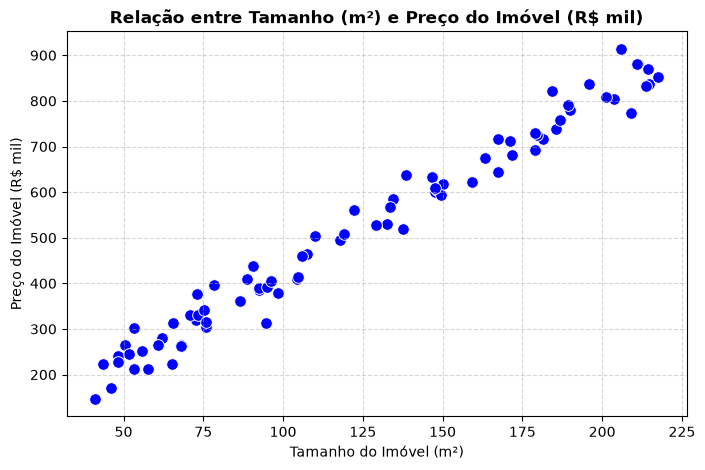

In [3]:
# 1. Criamos a figura gráfica com dimensão 8x5 polegadas
plt.figure(figsize=(8, 5))

# 2. Desenhamos o gráfico de dispersão relacionando tamanho do imóvel (X) e preço (Y)
sns.scatterplot(data=tabela_imoveis, x='tamanho_m2', y='preco_k', color='blue', s=70)

# 3. Adicionamos os rótulos aos eixos do gráfico
plt.title("Relação entre Tamanho (m²) e Preço do Imóvel (R$ mil)", fontweight='bold')
plt.xlabel("Tamanho do Imóvel (m²)")
plt.ylabel("Preço do Imóvel (R$ mil)")
plt.grid(True, linestyle='--', alpha=0.5)

# 4. Renderizamos o gráfico no notebook
print("🎨 Exibindo o gráfico de dispersão imobiliária no Colab...")
plt.show()

---

### Bloco 3.4 — Separação das Matrizes X e Target y com Reshape

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Por que precisamos do `.reshape(-1, 1)` no `X`?**  
> O Scikit-Learn exige obrigatoriamente que a matriz de entradas `X` seja uma **tabela bidimensional (2D)**. O `.reshape(-1, 1)` transforma o vetor de 80 números em uma matriz de 80 linhas por 1 coluna. O `y` pode continuar como vetor 1D.

In [4]:
# 1. Extraímos o atributo de entrada X e aplicamos o reshape(-1, 1) para gerar uma matriz 2D
matriz_entradas_x = tabela_imoveis['tamanho_m2'].values.reshape(-1, 1)

# 2. Extraímos o vetor de respostas y mantendo o formato 1D de lista de números
vetor_respostas_y = tabela_imoveis['preco_k'].values

# 3. Exibimos a forma estrutural de ambas as variáveis
print("--- SEPARAÇÃO DAS ESTRUTURAS DE DADOS ---")
print(f"📐 Dimensão da Matriz X de Entrada: {matriz_entradas_x.shape}  (80 linhas, 1 coluna)")
print(f"📐 Dimensão do Vetor y de Saída:    {vetor_respostas_y.shape}  (80 valores, sem coluna)")

--- SEPARAÇÃO DAS ESTRUTURAS DE DADOS ---
📐 Dimensão da Matriz X de Entrada: (80, 1)  (80 linhas, 1 coluna)
📐 Dimensão do Vetor y de Saída:    (80,)  (80 valores, sem coluna)


---

### Bloco 3.5 — Divisão dos Dados em Treino e Teste (`train_test_split`)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Por que dividimos os dados em treino e teste?**  
> Se avaliarmos o modelo nos mesmos dados em que ele treinou, ele pode apenas "decorar a prova". Reservar 20% para teste permite medir se ele é capaz de prever corretamente o preço de casas novas que ele nunca viu antes!

In [5]:
# 1. Separamos 80% dos dados para treino e 20% para teste fixando a semente com random_state=42
matriz_entradas_treino, matriz_entradas_teste, vetor_respostas_treino, vetor_respostas_teste = train_test_split(
    matriz_entradas_x, 
    vetor_respostas_y, 
    test_size=0.20,   # 20% dos dados reservados para o teste final
    random_state=42   # Semente fixa para resultados reproduzíveis
)

# 2. Exibimos a contagem de amostras reservadas para cada etapa
print("--- DIVISÃO DE DADOS (TREINO E TESTE) ---")
print(f"📦 Amostras para TREINAR o modelo (80%): {len(matriz_entradas_treino)}")
print(f"🧪 Amostras para TESTAR o modelo  (20%): {len(matriz_entradas_teste)}")

--- DIVISÃO DE DADOS (TREINO E TESTE) ---
📦 Amostras para TREINAR o modelo (80%): 64
🧪 Amostras para TESTAR o modelo  (20%): 16


---

### Bloco 3.6 — Instanciação, Treinamento (`fit`) e Inspeção de Coeficientes

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que indicam os atributos `coef_` e `intercept_`?**  
> - `coef_`: é o valor da inclinação $a$ (quanto o preço aumenta para cada $1m²$ a mais).  
> - `intercept_`: é o valor base $b$ (o preço teórico da casa se o tamanho fosse $0m²$).

In [6]:
# 1. Instanciamos o objeto da Regressão Linear (modelo vazio)
modelo_regressao_linear = LinearRegression()

# 2. O MOMENTO DO APRENDIZADO: O algoritmo lê os dados de treino e descobre a melhor reta
modelo_regressao_linear.fit(matriz_entradas_treino, vetor_respostas_treino)

# 3. Extraímos a inclinação 'a' (coef_) e o ponto inicial 'b' (intercept_) aprendidos
coeficiente_angular_a = modelo_regressao_linear.coef_[0]
coeficiente_linear_b = modelo_regressao_linear.intercept_

# 4. Exibimos a equação matemática aprendida no console
print("--- PARÂMETROS APRENDIDOS PELA IA (EQUAÇÃO DA RETA) ---")
print(f"🔍 Coeficiente Angular (a - Preço por m²): R$ {coeficiente_angular_a:.2f} mil por m²")
print(f"🔍 Coeficiente Linear  (b - Valor Base):   R$ {coeficiente_linear_b:.2f} mil")
print(f"\n📐 Equação Matemática Aprendida: Preço = ({coeficiente_angular_a:.2f} * m²) + {coeficiente_linear_b:.2f}")
print("👉 Ou seja: para cada m² a mais, o preço sobe o valor de 'a'. Com 0 m² (base), o preço seria 'b'.")

--- PARÂMETROS APRENDIDOS PELA IA (EQUAÇÃO DA RETA) ---
🔍 Coeficiente Angular (a - Preço por m²): R$ 3.86 mil por m²
🔍 Coeficiente Linear  (b - Valor Base):   R$ 36.27 mil

📐 Equação Matemática Aprendida: Preço = (3.86 * m²) + 36.27
👉 Ou seja: para cada m² a mais, o preço sobe o valor de 'a'. Com 0 m² (base), o preço seria 'b'.


---

### Bloco 3.7 — Plotagem da Reta de Regressão Aprendida sobre os Dados

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **Como a reta vermelha é desenhada sobre os pontos de treino?**  
> O comando `modelo.predict(treino)` calcula a altura $Y$ exata da reta para cada tamanho de imóvel $X$. A linha vermelha conecta todas essas previsões em uma reta perfeita!

🎨 Exibindo o ajuste da Reta de Regressão no Colab...


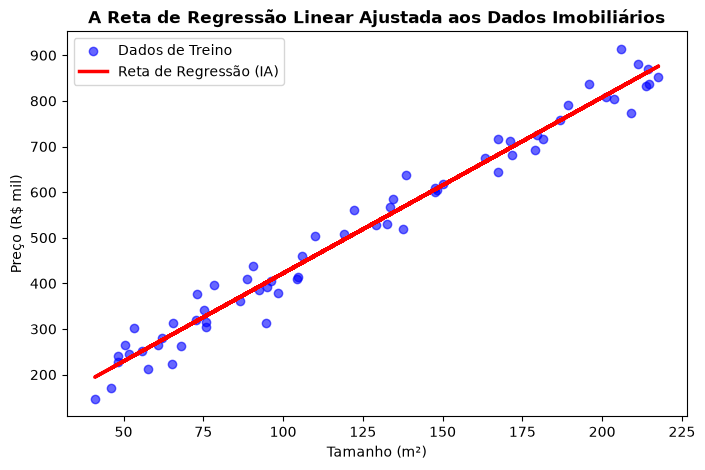

In [7]:
# 1. Definimos o tamanho do gráfico
plt.figure(figsize=(8, 5))

# 2. Desenhamos os pontos de treino originais em azul
plt.scatter(matriz_entradas_treino, vetor_respostas_treino, color='blue', alpha=0.6, label='Dados de Treino')

# 3. Desenhamos a linha reta ajustada pelo algoritmo da IA em vermelho
plt.plot(matriz_entradas_treino, modelo_regressao_linear.predict(matriz_entradas_treino), color='red', linewidth=2.5, label='Reta de Regressão (IA)')

# 4. Adicionamos rótulos e legenda ao gráfico
plt.title("A Reta de Regressão Linear Ajustada aos Dados Imobiliários", fontweight='bold')
plt.xlabel("Tamanho (m²)")
plt.ylabel("Preço (R$ mil)")
plt.legend()

# 5. Exibimos o gráfico no notebook
print("🎨 Exibindo o ajuste da Reta de Regressão no Colab...")
plt.show()

---

### Bloco 3.8 — Predição (`predict`) e Avaliação com Métricas ($R^2$, MAE)

> [!IMPORTANT]
> 🤔 **Dúvidas Comuns de Iniciantes:**  
> **O que significam os resultados de $R^2$ e MAE?**  
> - **MAE (Erro Médio Absoluto):** informa quanto o modelo erra em média na moeda real (ex: R$ 15 mil).  
> - **$R^2$ Score:** informa qual a porcentagem da variação dos preços é explicada pelo tamanho da casa (ex: $90\%$).

In [8]:
# 1. Geramos as previsões de preço para o conjunto de TESTE reservado
previsoes_precos_teste = modelo_regressao_linear.predict(matriz_entradas_teste)

# 2. Calculamos o coeficiente de determinação R² Score
pontuacao_r2 = r2_score(vetor_respostas_teste, previsoes_precos_teste)

# 3. Calculamos o Erro Médio Absoluto (MAE) em milhares de reais
erro_medio_absoluto = mean_absolute_error(vetor_respostas_teste, previsoes_precos_teste)

# 4. Exibimos os relatórios numéricos no console
print("--- AVALIAÇÃO DE DESEMPENHO NO CONJUNTO DE TESTE ---")
print(f"📊 R² Score (Precisão Explicada):    {pontuacao_r2 * 100:.2f}%")
print(f"📊 Erro Médio Absoluto (MAE):        R$ {erro_medio_absoluto * 1000:,.2f}")
print("👉 Quanto mais perto de 100% no R² e mais perto de R$ 0 no MAE, melhor é o modelo!")

--- AVALIAÇÃO DE DESEMPENHO NO CONJUNTO DE TESTE ---
📊 R² Score (Precisão Explicada):    98.36%
📊 Erro Médio Absoluto (MAE):        R$ 21,761.78
👉 Quanto mais perto de 100% no R² e mais perto de R$ 0 no MAE, melhor é o modelo!


---

## Módulo 4: Prática Orientada & Experimentação Fácil

### Roteiro de Personalização para o Estudante:
Altere o peso do veículo no código abaixo para calcular a estimativa de consumo de combustível do seu carro:

1. **Digite o peso do seu veículo:** Na linha `peso_veiculo_toneladas = 1.4` (em toneladas, ex: 1.4 ton = 1400kg), coloque o peso desejado.
2. **Re-execute e observe:** Veja quantos km/l a IA prevê para um carro com esse peso!

In [9]:
# =============================================================================
# CÓDIGO BASE PRONTO PARA SUA EXPERIMENTAÇÃO
# =============================================================================
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Geramos dados sintéticos reproduzíveis de peso (ton) vs consumo (km/l)
np.random.seed(123)
peso_toneladas = np.random.uniform(0.8, 2.5, size=50)
consumo_kml = 18.0 - 4.5 * peso_toneladas + np.random.normal(0, 0.5, size=50)

# 2. Preparamos as matrizes de dados de entrada e saída
matriz_carros_x = peso_toneladas.reshape(-1, 1)
vetor_carros_y = consumo_kml

# 3. Instanciamos e treinamos o modelo de Regressão Linear dos veículos
modelo_consumo_carros = LinearRegression().fit(matriz_carros_x, vetor_carros_y)

# -----------------------------------------------------------------------------
# STEP 1: PASSO DE EXPERIMENTAÇÃO DO ALUNO — ALTERE O PESO DO CARRO ABAIXO:
# -----------------------------------------------------------------------------
peso_veiculo_toneladas = 1.4 # Tente mudar para 1.0 (1000kg) ou 2.2 (2200kg)

# 4. A IA realiza a previsão para a entrada do estudante
consumo_estimado_kml = modelo_consumo_carros.predict([[peso_veiculo_toneladas]])[0]

# 5. Exibimos a previsão final
print(f"--- RELATÓRIO DO SEU CARRO PERSONALIZADO ---")
print(f"🚗 Peso Informado: {peso_veiculo_toneladas} toneladas ({peso_veiculo_toneladas * 1000:.0f} kg)")
print(f"⛽ Consumo Estimado pela IA: ---> {consumo_estimado_kml:.2f} km/l <---")

--- RELATÓRIO DO SEU CARRO PERSONALIZADO ---
🚗 Peso Informado: 1.4 toneladas (1400 kg)
⛽ Consumo Estimado pela IA: ---> 11.78 km/l <---


---

### 🔮 Aquecimento & Spoiler da Próxima Aula (Para Ir Além)

> [!TIP]
> 🧠 **Conceito-Semente — Por que uma reta infinita falha para perguntas de 'Sim ou Não'?**  
> Se tentarmos traçar uma reta para prever se um paciente está doente ($1$) ou saudável ($0$), a reta pode prever valores absurdos como $1.8$ ou $-0.4$. Na **Aula 08**, conheceremos a **Regressão Logística** (que usa a elegante curva Sigmoide para espremer as saídas entre $0\%$ e $100\%$) e o intuitivo algoritmo **KNN** (*'Diga-me com quem andas e te direi quem és'*).
> 
> 🚀 **Desafio Proativo de Autoestudo (Opcional):**  
> Se um sistema de IA de um hospital disser que um paciente tem 51% de chance de ter uma doença grave, você o mandaria para casa ou pediria exames extras? Reflita sobre como o limiar de decisão (*threshold*) impacta a vida real!

---

## Módulo 5: Checklist de Autonomia do Estudante

- [ ] Compreendi a diferença prática entre problemas de Regressão e Classificação.
- [ ] Entendi a intuição matemática da reta de regressão ($y = a \cdot x + b$).
- [ ] Sei importar e utilizar o `train_test_split` do Scikit-Learn.
- [ ] Consigo instanciar, treinar (`fit`) e fazer previsões (`predict`) com o `LinearRegression`.
- [ ] Sei alterar o peso de entrada no meu script e observar a previsão personalizada.

---

## Referências Bibliográficas & Documentações Oficiais

- 📖 **Livro Texto Principal:** Géron, A. — *Mãos à Obra: Aprendizado de Máquina com Scikit-Learn, Keras & TensorFlow* (Capítulo 4: Treinando Modelos).
- 🔗 **Documentação Scikit-Learn:** [scikit-learn LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

---

# 🧪 Extensão Prática Avançada: Laboratório Técnico com Dados Reais (`pratica_real.md`)

> 🔬 **Sobre esta Extensão:**  
> Esta seção adicional consolida o aprendizado com uma abordagem **mais avançada, direta e profissional**, sem dados sintéticos e utilizando datasets reais consagrados da Ciência de Dados.


# Laboratório Prático — Aula 07: Regressão Linear Simples e Múltipla

**Disciplina:** Aprendizado de Máquina e Redes Neurais  
**Professor:** Eduardo Lázaro Roesler de Oliveira  
**Instituição:** UNIVEM — Centro Universitário de Marília  
**Dataset Real:** *California Housing Dataset* (20.640 distritos censitários da Califórnia)

---

## 🎯 Objetivo do Laboratório
Treinar um modelo de Regressão Linear Múltipla para prever o valor mediano de imóveis ($y$) a partir de variáveis econômicas e estruturais ($X$): realizar divisão treino/teste com `train_test_split`, treinar o regressor com `fit`, interpretar os coeficientes aprendidos e mensurar o erro com $R^2$, MAE e RMSE.

---

### Passo 1 — Carregando os Dados Imobiliários Reais

In [10]:
from sklearn.datasets import fetch_california_housing
import pandas as pd
import numpy as np

# 1. Carregamos o dataset oficial em formato DataFrame
dados_california = fetch_california_housing(as_frame=True)
df_casas = dados_california.frame

print("--- 5 PRIMEIRAS LINHAS DOS IMÓVEIS ---")
print(df_casas.head())
print(f"\nTotal de distritos imobiliários: {df_casas.shape[0]}")

--- 5 PRIMEIRAS LINHAS DOS IMÓVEIS ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Total de distritos imobiliários: 20640


---

### Passo 2 — Definição das Matrizes $X$ e Vetor Alvo $y$

In [11]:
# 1. Entradas: Renda Mediana (MedInc), Idade da Casa (HouseAge) e Cômodos (AveRooms)
atributos_selecionados = ['MedInc', 'HouseAge', 'AveRooms']
X = df_casas[atributos_selecionados]

# 2. Alvo: Valor Mediano da Casa em centenas de milhares de dólares (MedHouseVal)
y = df_casas['MedHouseVal']

print(f"Dimensão da Matriz X: {X.shape}")
print(f"Dimensão do Alvo y:   {y.shape}")

Dimensão da Matriz X: (20640, 3)
Dimensão do Alvo y:   (20640,)


---

### Passo 3 — Divisão em Treino (80%) e Teste (20%)

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Casas para Treino: {len(X_train)}")
print(f"Casas para Teste:  {len(X_test)}")

Casas para Treino: 16512
Casas para Teste:  4128


---

### Passo 4 — Treinamento do Modelo e Inspeção de Coeficientes

In [13]:
from sklearn.linear_model import LinearRegression

# 1. Instanciamos e treinamos o modelo
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# 2. Exibimos os coeficientes da equação: y = b0 + b1*MedInc + b2*HouseAge + b3*AveRooms
print(f"Intercepto (b0): {regressor.intercept_:.4f}")
for nome_col, peso in zip(atributos_selecionados, regressor.coef_):
    print(f"Coeficiente ({nome_col}): {peso:+.4f}")

Intercepto (b0): 0.0173
Coeficiente (MedInc): +0.4448
Coeficiente (HouseAge): +0.0168
Coeficiente (AveRooms): -0.0281


---

### Passo 5 — Predição e Avaliação Formal de Métricas ($R^2$, MAE, RMSE)

In [14]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Fazemos as predições no conjunto de teste
y_pred = regressor.predict(X_test)

# 2. Calculamos as métricas de performance
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("--- MÉTRICAS NO CONJUNTO DE TESTE ---")
print(f"R² (Coeficiente de Determinação): {r2 * 100:.2f}%")
print(f"MAE (Erro Médio Absoluto):        ${mae * 100000:.2f} dólares")
print(f"RMSE (Raiz do Erro Quadrático):   ${rmse * 100000:.2f} dólares")

--- MÉTRICAS NO CONJUNTO DE TESTE ---
R² (Coeficiente de Determinação): 49.72%
MAE (Erro Médio Absoluto):        $60332.14 dólares
RMSE (Raiz do Erro Quadrático):   $81173.32 dólares


---

## 🏆 Desafio Técnico de Validação
Treine um segundo modelo utilizando **todas as 8 colunas** do dataset original (`X = df_casas.drop(columns=['MedHouseVal'])`) e verifique se o $R^2$ do modelo sobe para acima de $60\%$.

In [15]:
# =============================================================================
# ESPAÇO PARA RESOLUÇÃO DO DESAFIO TÉCNICO
# Implemente seu código abaixo para validar o desafio proposto:
# =============================================================================
